# Programming Assignment 1

Segmentação de instâncias com as arquiteturas da aula

Equipe: Jaime Willian Carneiro da Silva & Luiz Eduardo Bravin

## Datasets 

Escolheremos a opção A - DSB2018 / BBBC038v1

Download:  https://bbbc.broadinstitute.org/BBBC038

## Modelo

- falar sobre o modelo escolhido: Unet Binaria e D dimensional

## Métricas

- mostrar como as metricas estao sendo calculadas

A regra de matching utilizada foi a guloso por IoU.

In [1]:
# Importacao de arquivos
import sys
import os
sys.path.append(os.path.abspath('..')) 
%load_ext autoreload
%autoreload 2
from src import *

# Importacao de bibliotecas
import torch
import numpy as np
from pathlib import Path
from torch.utils.data import DataLoader, random_split
import time

# Configurações gerais
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'xpu' if hasattr(torch, 'xpu') and torch.xpu.is_available() else 'cpu')
BATCH_SIZE = 16

## Parte 0

Quanto maior a quantidade de elipses, maior facilidade de ter intersecção entre elas. Com isso, o modelo interpreta como se fosse apenas um objeto, logo diminuindo o mAP e aumentando o erro absoluto de contagem. 

In [2]:
# Configurações
model = UNetBinary()
model.to(DEVICE)
part = 1

# Dataset
train_dataset = SyntheticEllipseDataset(num_samples=536, img_size=128, part=part)
val_dataset = SyntheticEllipseDataset(num_samples=134, img_size=128, part=part)
test_dataset = SyntheticEllipseDataset(num_samples=65, img_size=128, part=part)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)

# Treinamento
start = time.time()
history = training1(
            model=model,
            dataloader=train_loader,
            device=DEVICE
)
print(f'Tempo de treinamento: {(time.time() - start)/60:.2f} minutos')

Treinando em: xpu
Batches por época: 34
Epoch 1/10 | Loss: 0.6530 | IoU: 0.5257 | Dice: 0.6891
Epoch 2/10 | Loss: 0.3271 | IoU: 0.8560 | Dice: 0.9224
Epoch 3/10 | Loss: 0.1339 | IoU: 0.9561 | Dice: 0.9776
Epoch 4/10 | Loss: 0.0604 | IoU: 0.9623 | Dice: 0.9808
Epoch 5/10 | Loss: 0.0434 | IoU: 0.9721 | Dice: 0.9858
Epoch 6/10 | Loss: 0.0378 | IoU: 0.9758 | Dice: 0.9877
Epoch 7/10 | Loss: 0.0325 | IoU: 0.9791 | Dice: 0.9894
Epoch 8/10 | Loss: 0.0276 | IoU: 0.9829 | Dice: 0.9914
Epoch 9/10 | Loss: 0.0245 | IoU: 0.9848 | Dice: 0.9924
Epoch 10/10 | Loss: 0.0214 | IoU: 0.9876 | Dice: 0.9938
Tempo de treinamento: 1.34 minutos


Média global mAP: 0.0941
Média global Erro Absoluto de Contagem: 9.9104


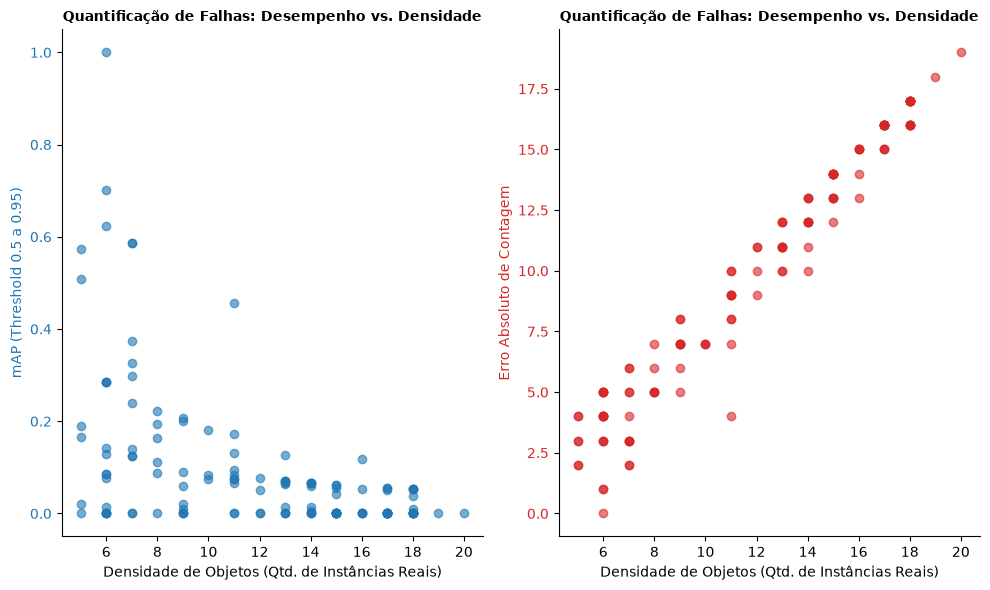

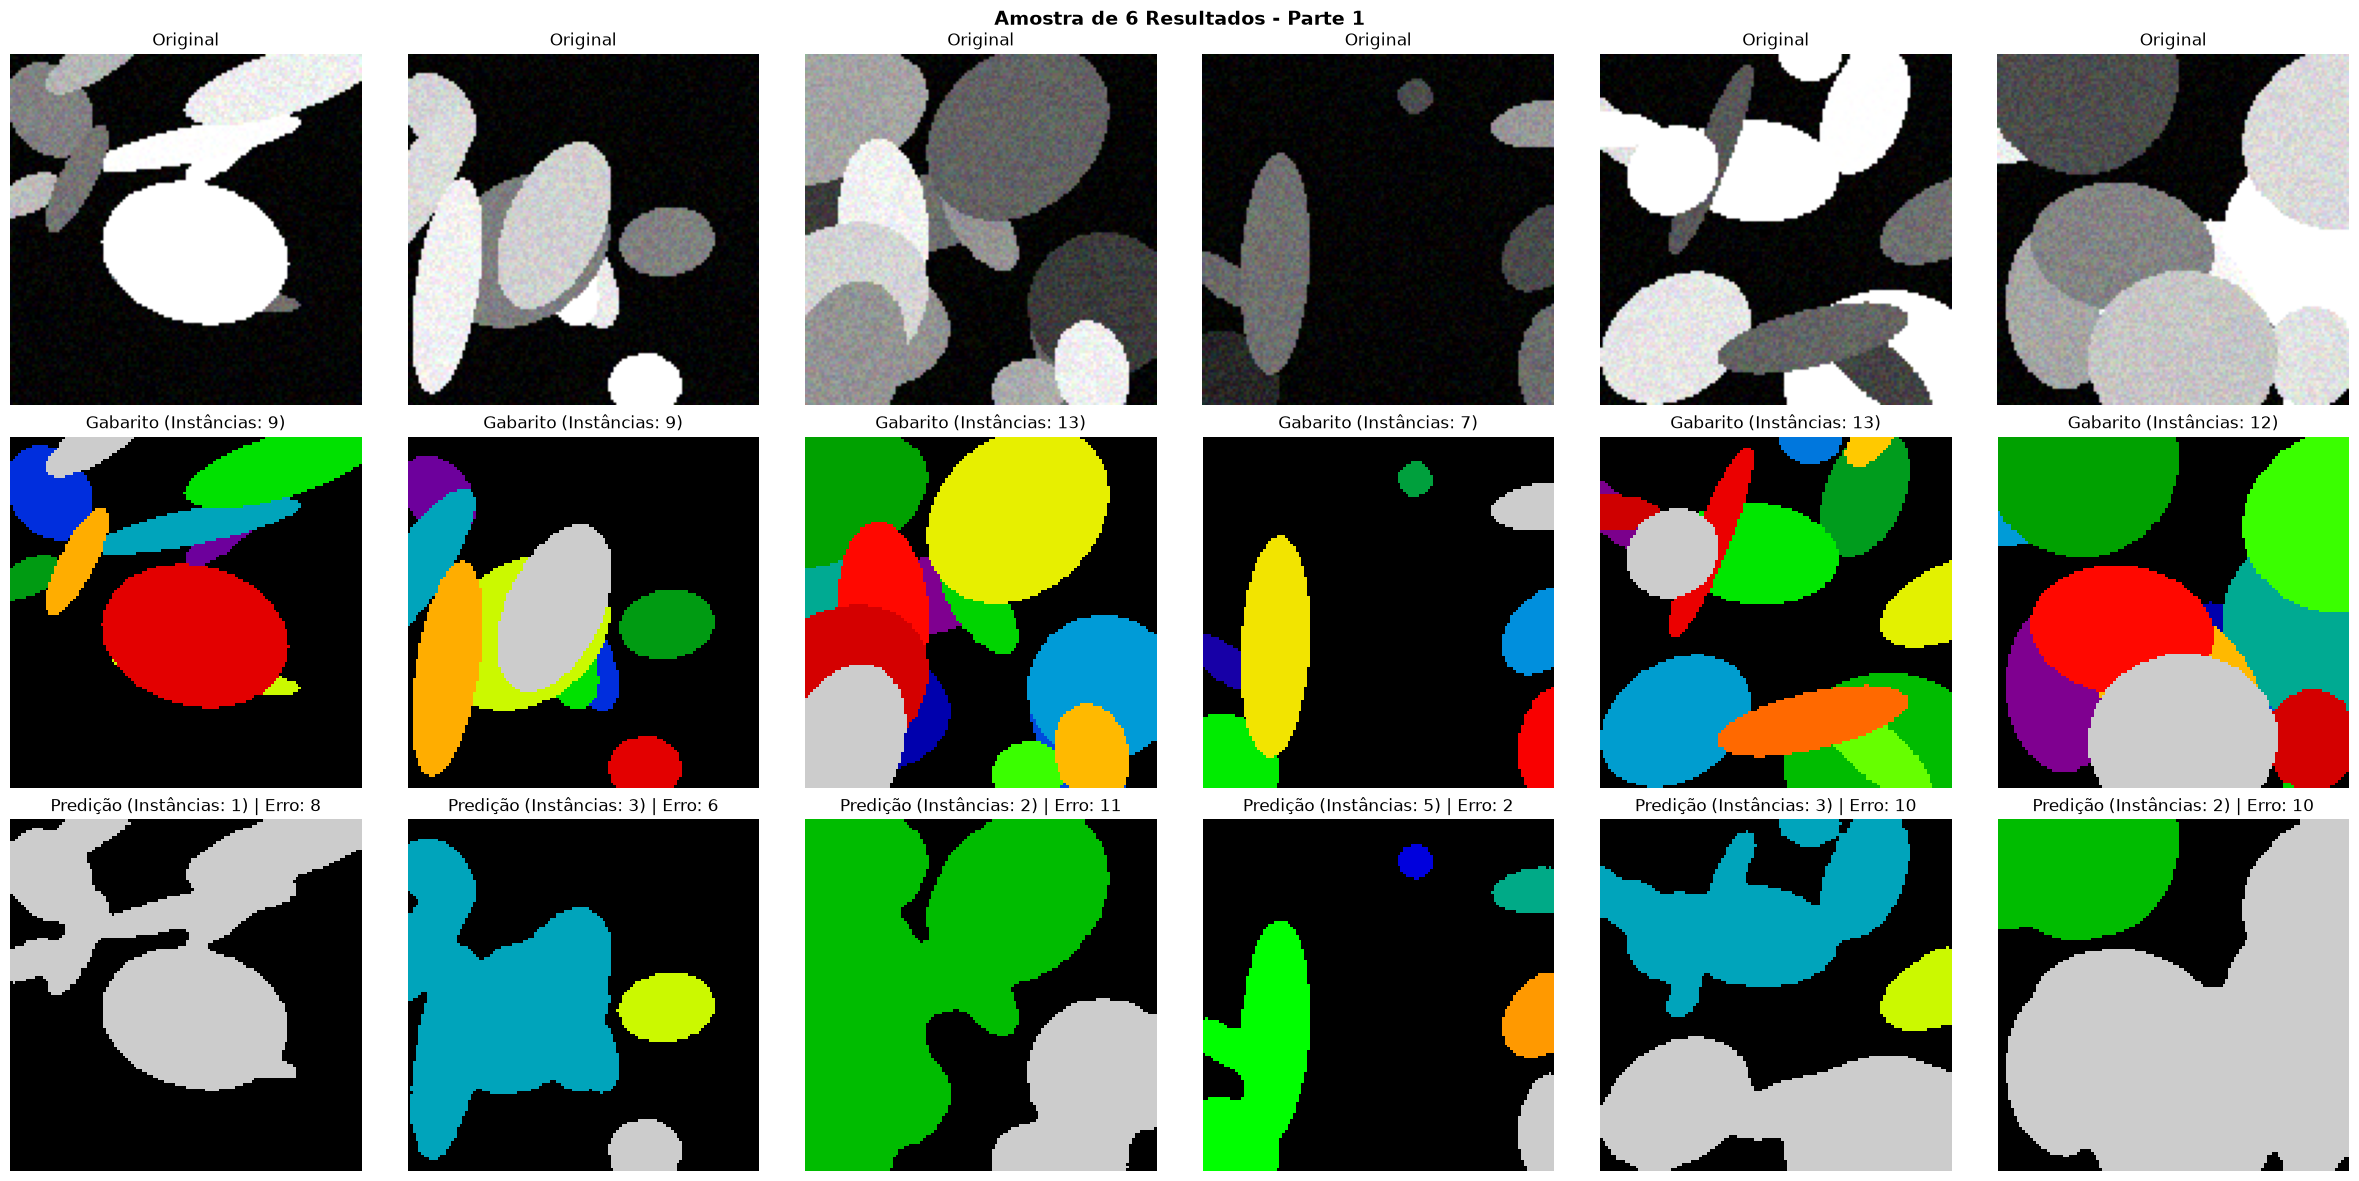

In [3]:
real_mAP, real_count_errors, real_densities, real_samples = evaluate1(model, val_loader, DEVICE)

# Plotando métricas e amostras
plot_metrics(real_mAP, real_count_errors, real_densities)
plot_samples(real_samples, part=part)

## Parte 01

In [4]:
# Consigurações
model = UNetBinary()
model.to(DEVICE)
part = 1

# Dataset
path_train = Path('../data/stage1_train')
path_test = Path('../data/stage1_test')
full_dataset = DSB2018Dataset(root_dir=path_train, img_size=128,  part=part, cache_in_memory=True)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])
test_dataset = DSB2018Dataset(root_dir=path_test, img_size=128,  part=part, cache_in_memory=True)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)

# Treinamento
start = time.time()
history = training1(
            model=model,
            dataloader=train_loader,
            device=DEVICE
)
print(f'Tempo de treinamento: {(time.time() - start)/60:.2f} minutos')


Treinando em: xpu
Batches por época: 34
Epoch 1/10 | Loss: 0.5744 | IoU: 0.0000 | Dice: 0.0000
Epoch 2/10 | Loss: 0.3409 | IoU: 0.0000 | Dice: 0.0000
Epoch 3/10 | Loss: 0.2765 | IoU: 0.0000 | Dice: 0.0000
Epoch 4/10 | Loss: 0.2180 | IoU: 0.1551 | Dice: 0.2685
Epoch 5/10 | Loss: 0.1698 | IoU: 0.5515 | Dice: 0.7110
Epoch 6/10 | Loss: 0.1397 | IoU: 0.6369 | Dice: 0.7782
Epoch 7/10 | Loss: 0.1275 | IoU: 0.6607 | Dice: 0.7957
Epoch 8/10 | Loss: 0.1158 | IoU: 0.6917 | Dice: 0.8177
Epoch 9/10 | Loss: 0.1123 | IoU: 0.7030 | Dice: 0.8256
Epoch 10/10 | Loss: 0.1036 | IoU: 0.7209 | Dice: 0.8378
Tempo de treinamento: 1.23 minutos


Média global mAP: 0.2921
Média global Erro Absoluto de Contagem: 15.1269


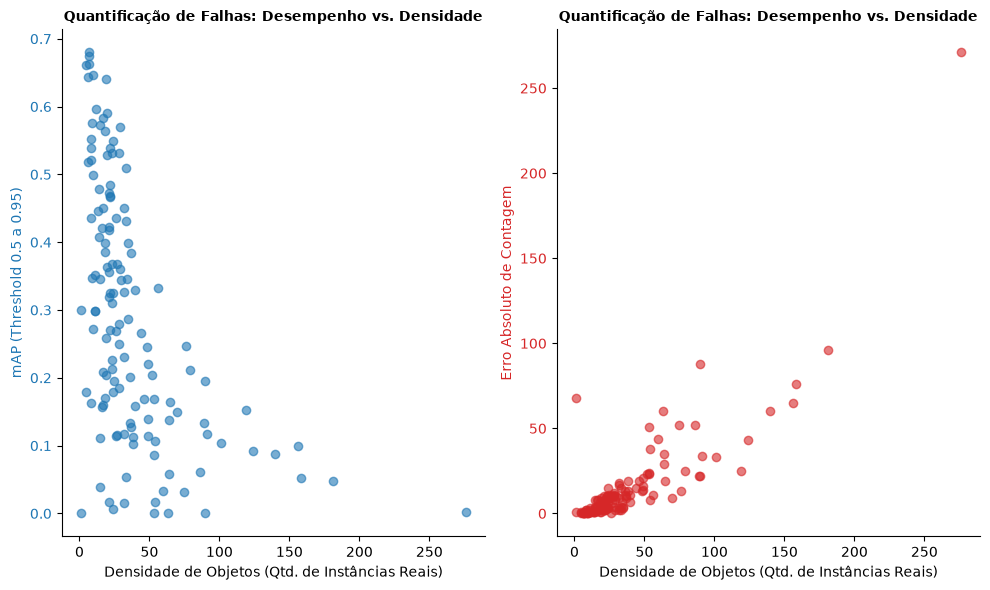

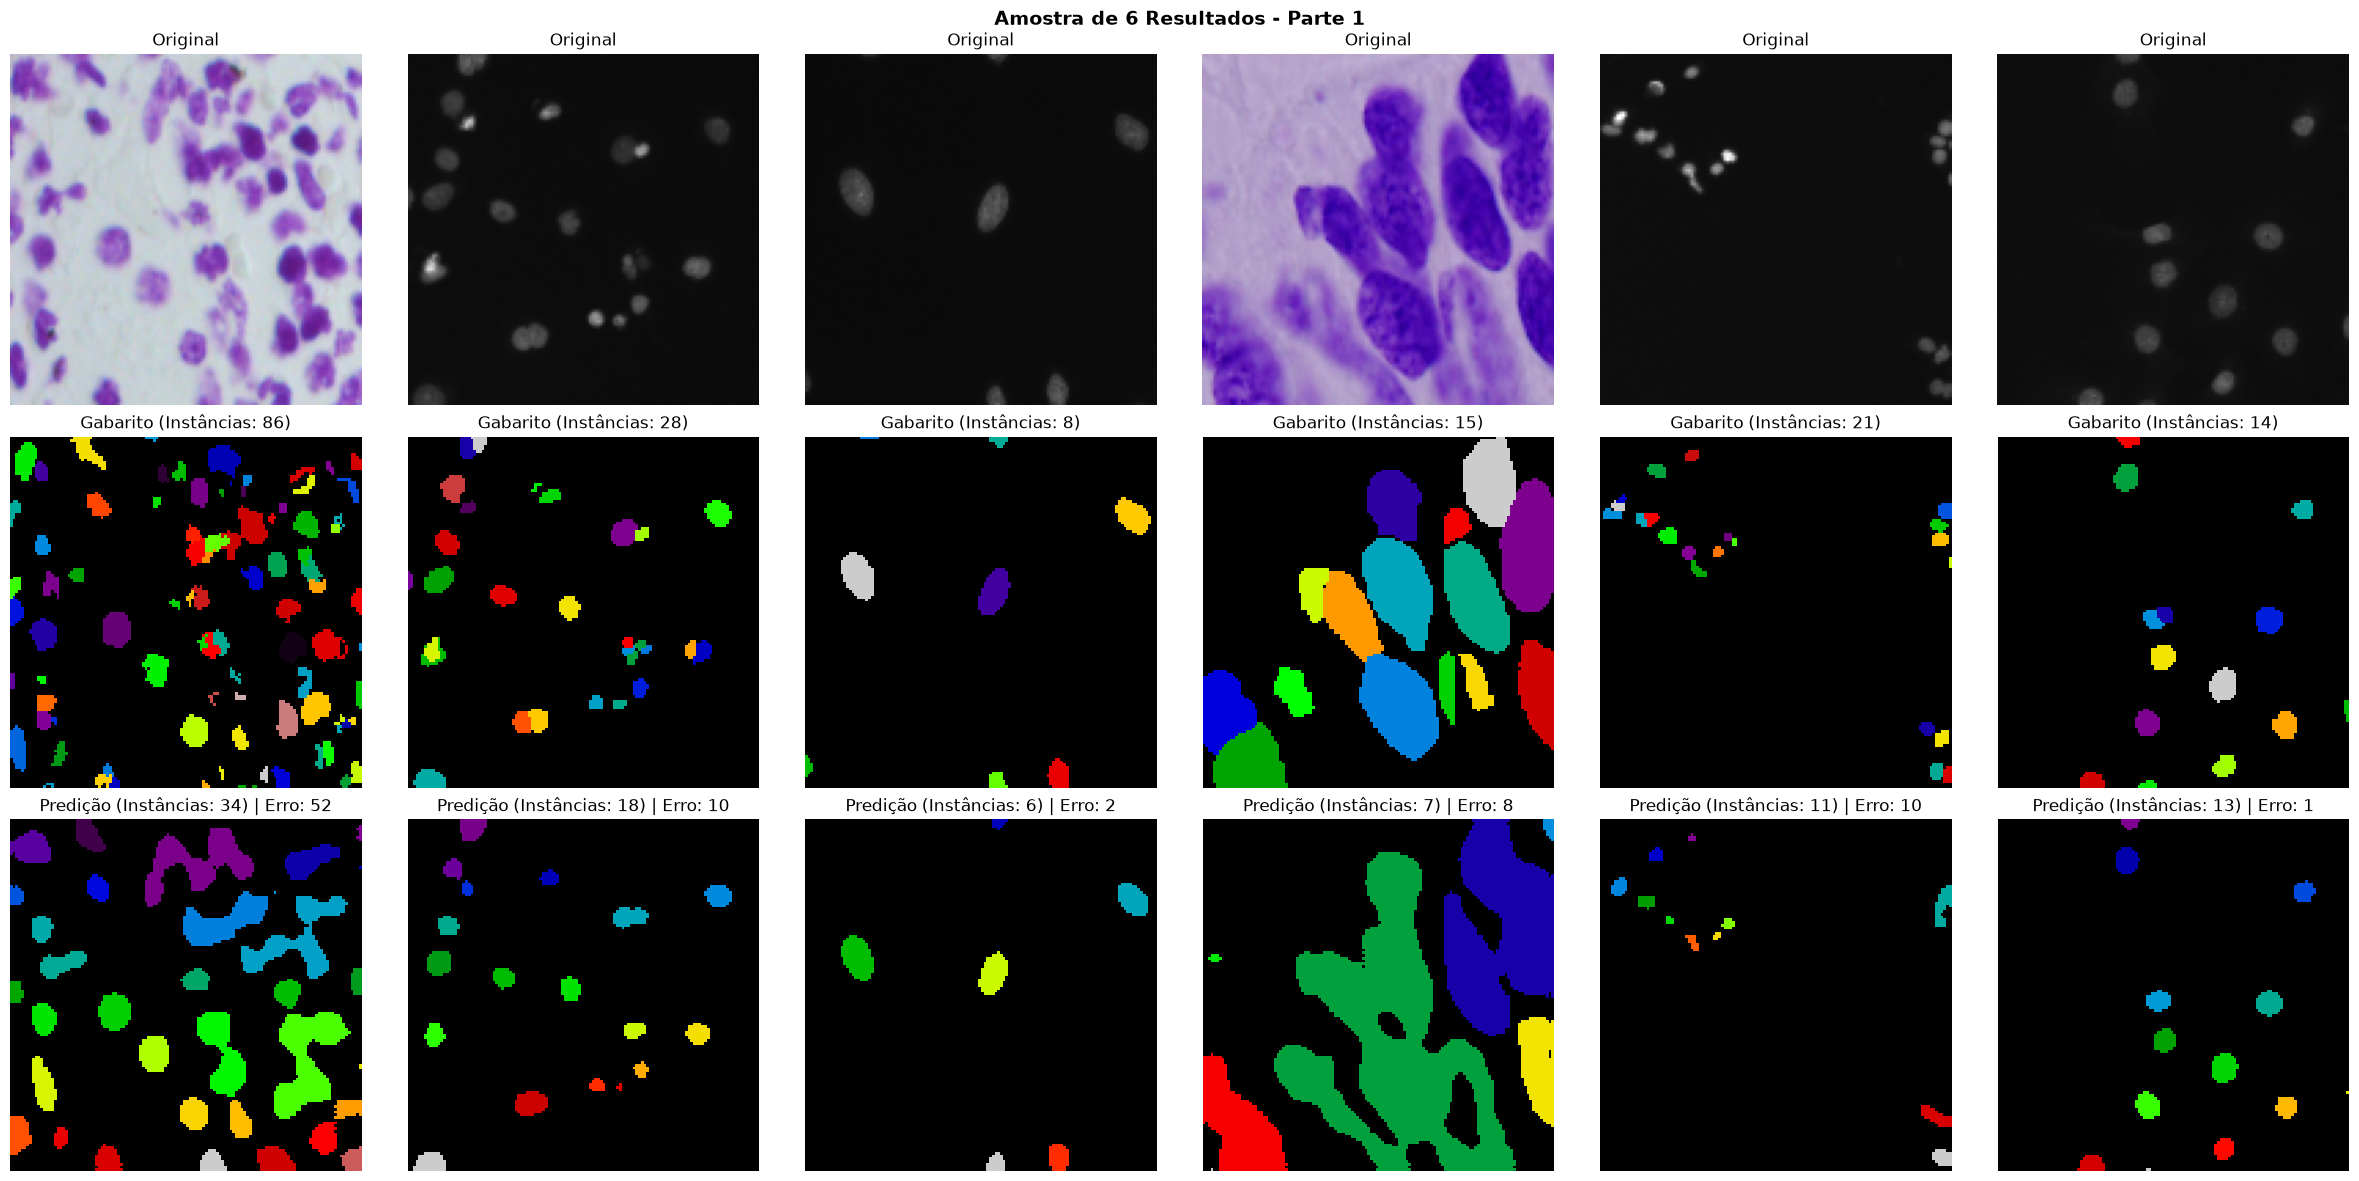

In [5]:
# Avaliação
real_mAP, real_count_errors, real_densities, real_samples = evaluate1(model, val_loader, DEVICE)

# Plotando métricas e amostras
plot_metrics(real_mAP, real_count_errors, real_densities)
plot_samples(real_samples, part=part)


## Parte 02

Parte 2 - Trilha B

In [6]:
# Consigurações
model = UNetTernary()
model.to(DEVICE)
part = 2

# Dataset
path_train = Path('../data/stage1_train')
path_test = Path('../data/stage1_test')
full_dataset = DSB2018Dataset(root_dir=path_train, img_size=128, part=part, cache_in_memory=True)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])
test_dataset = DSB2018Dataset(root_dir=path_test, img_size=128, part=part, cache_in_memory=True)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)

# Treinamento
start = time.time()
history = training2(
            model=model,
            dataset=train_dataset,
            dataloader=train_loader,
            device=DEVICE
)
print(f'Tempo de treinamento: {(time.time() - start)/60:.2f} minutos')


Treinando em: xpu
Batches por época: 34
Pesos CE (bg/interior/fronteira): [0.3858932554721832, 6.5716328620910645, 3.899538993835449]
Pesos Dice -> interior: 1.5 | fronteira: 1.0
Epoch 1/10 | Loss: 6.1550 | IoU: 0.0483 | Dice: 0.0922
Epoch 2/10 | Loss: 5.7034 | IoU: 0.0205 | Dice: 0.0401
Epoch 3/10 | Loss: 5.5383 | IoU: 0.0016 | Dice: 0.0032
Epoch 4/10 | Loss: 5.2649 | IoU: 0.1951 | Dice: 0.3266
Epoch 5/10 | Loss: 4.5023 | IoU: 0.4588 | Dice: 0.6290
Epoch 6/10 | Loss: 3.6745 | IoU: 0.5352 | Dice: 0.6973
Epoch 7/10 | Loss: 3.4007 | IoU: 0.5753 | Dice: 0.7304
Epoch 8/10 | Loss: 3.3767 | IoU: 0.5675 | Dice: 0.7241
Epoch 9/10 | Loss: 3.1744 | IoU: 0.6051 | Dice: 0.7540
Epoch 10/10 | Loss: 3.0242 | IoU: 0.6294 | Dice: 0.7726
Tempo de treinamento: 1.31 minutos


Média global mAP: 0.1629
Média global Erro Absoluto de Contagem: 20.9254


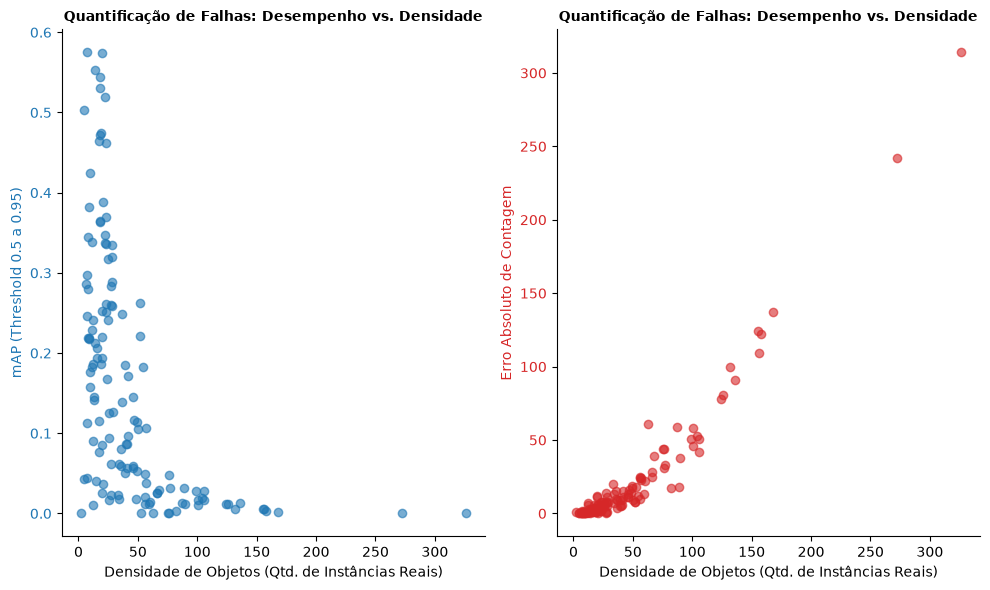

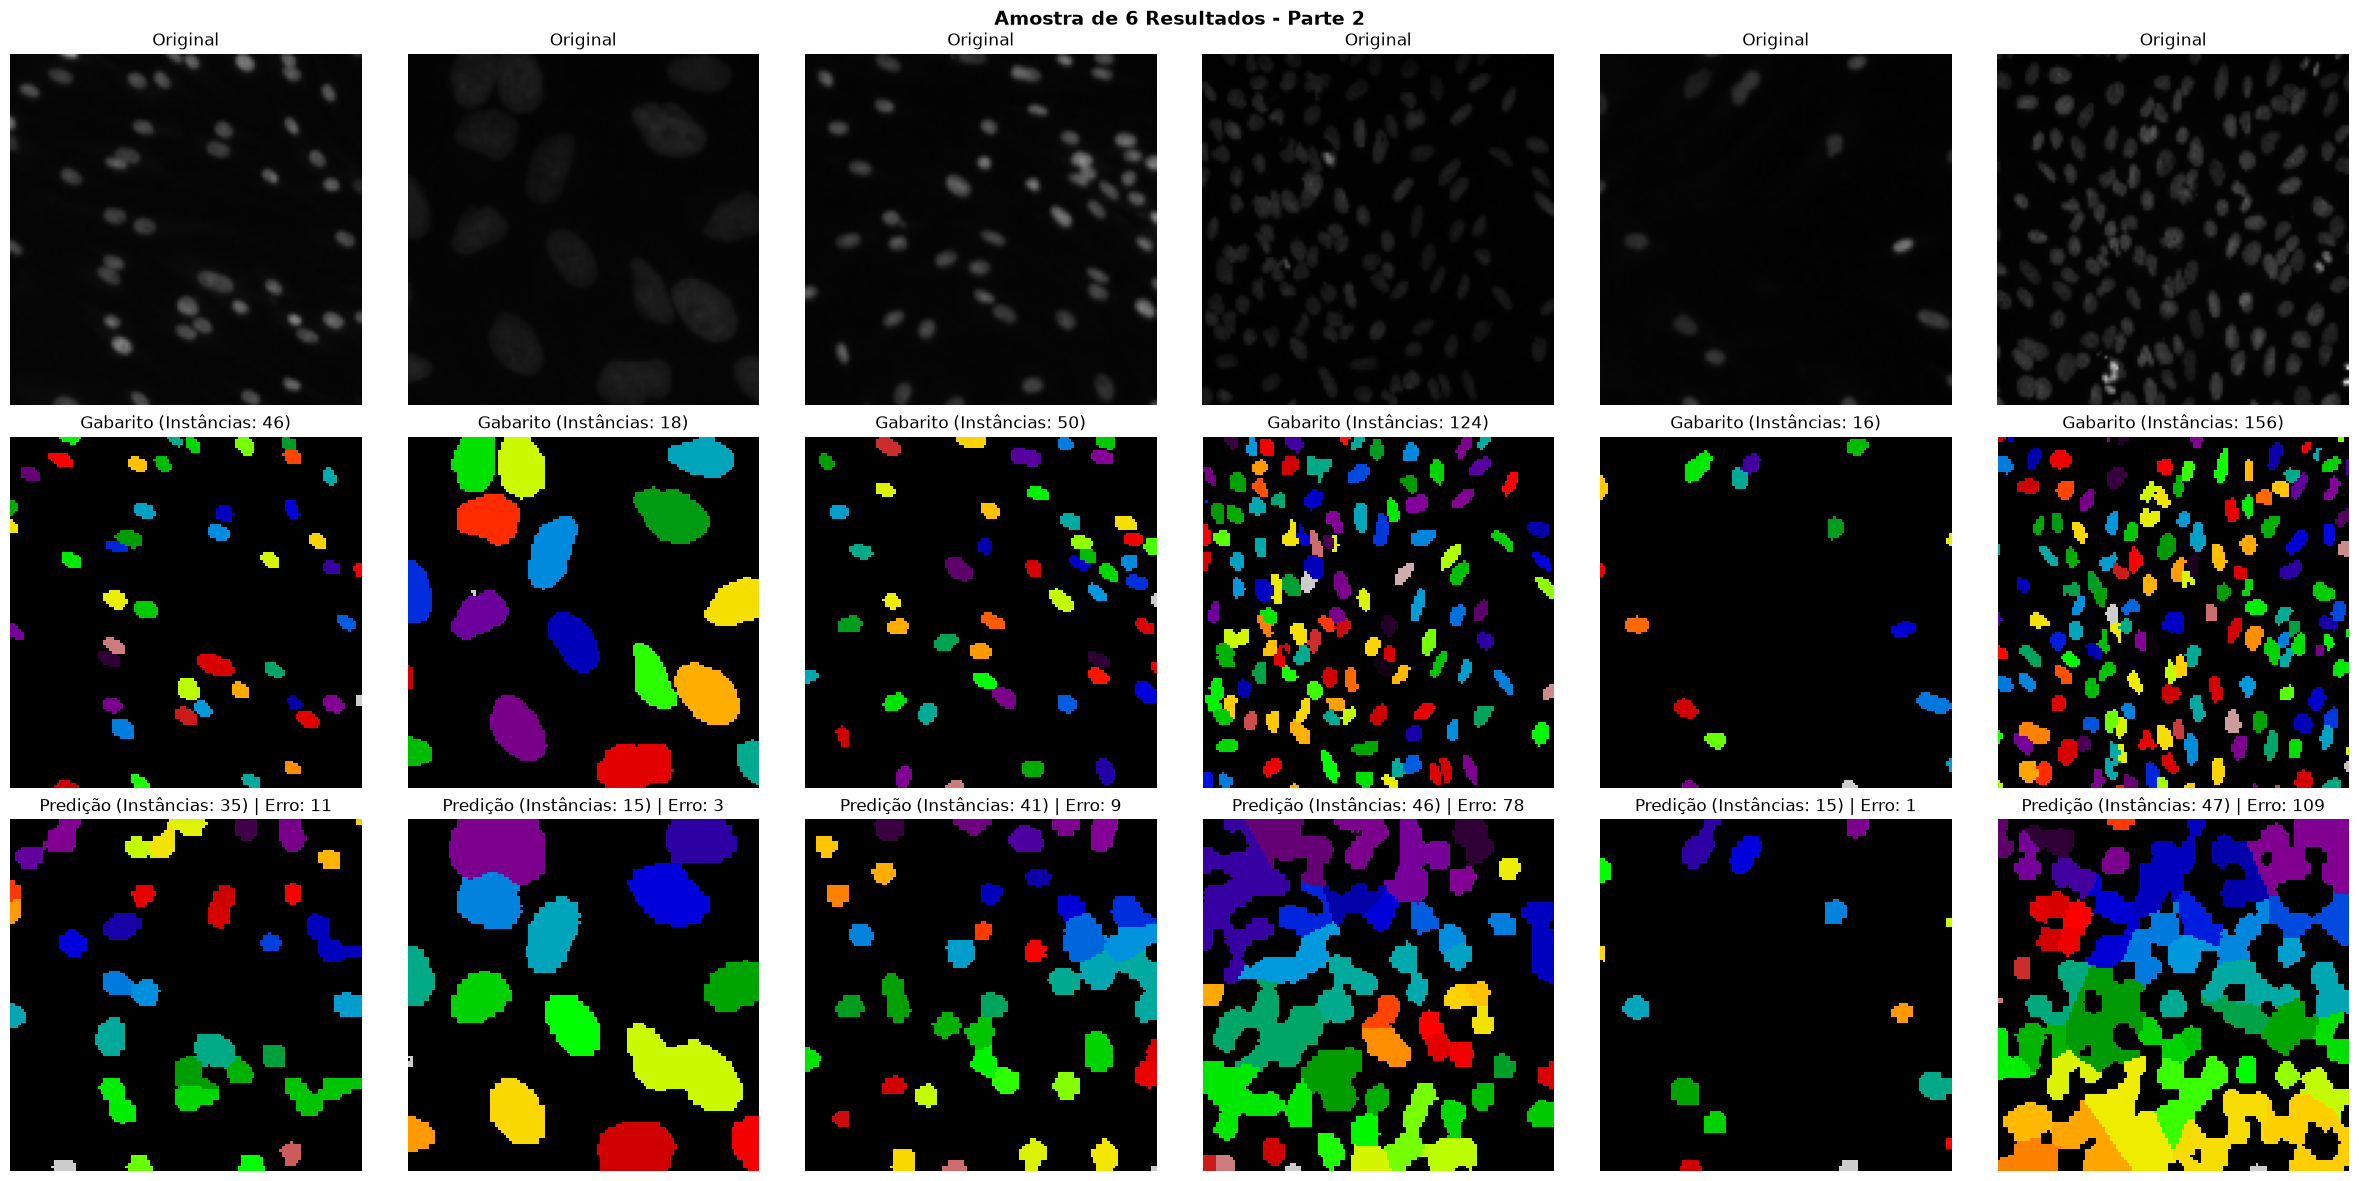

In [7]:
real_mAP, real_count_errors, real_densities, real_samples = evaluate2(model, val_loader, DEVICE)

# Plotando métricas e amostras
plot_metrics(real_mAP, real_count_errors, real_densities)
plot_samples(real_samples, part=part)

## Parte 03


## Parte 04

## Parte 05

## Parte 06